In [10]:
from keras.utils import to_categorical 
from tensorflow.keras.preprocessing.image import load_img
from keras.models import Sequential
from keras. layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D
import os
import pandas as pd 
import numpy as np

In [7]:
TRAIN_DIR='images/train'
TEST_DIR='images/test'

In [8]:
def createdataframe(dir):
   image_paths = []
   labels = []
   for label in os.listdir(dir):
        for imagename in os.listdir(os.path.join(dir,label)):
             image_paths.append(os.path.join(dir,label, imagename))
             labels.append(label)
        print(label, "completed")
   return image_paths,labels

In [11]:
train = pd.DataFrame()
train['image'], train['label']=createdataframe(TRAIN_DIR)

angry completed
disgust completed
fear completed
happy completed
neutral completed
sad completed
surprise completed


In [12]:
print(train)

                                image     label
0            images/train\angry\0.jpg     angry
1            images/train\angry\1.jpg     angry
2           images/train\angry\10.jpg     angry
3        images/train\angry\10002.jpg     angry
4        images/train\angry\10016.jpg     angry
...                               ...       ...
28816  images/train\surprise\9969.jpg  surprise
28817  images/train\surprise\9985.jpg  surprise
28818  images/train\surprise\9990.jpg  surprise
28819  images/train\surprise\9992.jpg  surprise
28820  images/train\surprise\9996.jpg  surprise

[28821 rows x 2 columns]


In [13]:
test = pd.DataFrame()
test['image'], test['label']=createdataframe(TEST_DIR)

angry completed
disgust completed
fear completed
happy completed
neutral completed
sad completed
surprise completed


In [14]:
print(test)

                              image     label
0       images/test\angry\10052.jpg     angry
1       images/test\angry\10065.jpg     angry
2       images/test\angry\10079.jpg     angry
3       images/test\angry\10095.jpg     angry
4       images/test\angry\10121.jpg     angry
...                             ...       ...
7061  images/test\surprise\9806.jpg  surprise
7062  images/test\surprise\9830.jpg  surprise
7063  images/test\surprise\9853.jpg  surprise
7064  images/test\surprise\9878.jpg  surprise
7065   images/test\surprise\993.jpg  surprise

[7066 rows x 2 columns]


In [15]:
from tqdm.notebook import tqdm

In [16]:
def extract_features(images):
     features = []
     for image in tqdm(images):
         img = load_img(image,color_mode="grayscale")
         img = np.array(img)
         features.append(img)
     features = np.array(features)
     features = features.reshape(len(features),48,48,1)
     return features

In [17]:
train_features = extract_features(train['image'])

  0%|          | 0/28821 [00:00<?, ?it/s]

In [18]:
test_features = extract_features(test['image'])

  0%|          | 0/7066 [00:00<?, ?it/s]

In [19]:
x_train = train_features/255.0
x_test = test_features/255.0

In [20]:
from sklearn.preprocessing import LabelEncoder

In [21]:
le = LabelEncoder()
le.fit(train['label'])

LabelEncoder()

In [22]:
y_train = le.transform(train['label'])
y_test = le.transform(test['label'])


In [23]:
y_train = to_categorical(y_train, num_classes = 7)
y_test = to_categorical(y_test,num_classes = 7)

In [41]:
model = Sequential()
# convolutional layers
model.add(Conv2D(128, kernel_size=(3,3), activation='relu', input_shape=(48,48,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(256, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Conv2D(512, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.4))

model.add(Flatten())
# fully connected layers
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.4))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
# output layer
model.add(Dense(7, activation='softmax'))

In [42]:
model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

In [43]:
model.fit(x= x_train,y = y_train, batch_size = 128, epochs = 100, validation_data = (x_test,y_test)) 

Epoch 1/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 240s 1s/step - accuracy: 0.2431 - loss: 1.8239 - val_accuracy: 0.2583 - val_loss: 1.8093
Epoch 2/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step - accuracy: 0.2480 - loss: 1.8099 - val_accuracy: 0.2638 - val_loss: 1.7941
Epoch 3/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.2703 - loss: 1.7607 - val_accuracy: 0.3230 - val_loss: 1.6784
Epoch 4/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.3299 - loss: 1.6680 - val_accuracy: 0.4147 - val_loss: 1.5392
Epoch 5/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 224s 990ms/step - accuracy: 0.3852 - loss: 1.5678 - val_accuracy: 0.4472 - val_loss: 1.4272
Epoch 6/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 227s 1s/step - accuracy: 0.4175 - loss: 1.4922 - val_accuracy: 0.4788 - val_loss: 1.3631
Epoch 7/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.4436 - loss: 1.4353 - val_accuracy: 0.4933 - val_loss: 1.3189
Epoch 8/100
226/226 ━━━━━━━━━━━━━━━━━━━━ 232s 1s/step - accuracy: 0.4640 - loss: 1.3951

KeyboardInterrupt: 

In [44]:
model_json = model.to_json()
with open("emotiondetector1.json",'w') as json_file:
    json_file.write(model_json)
model.save("emotiondetector1.h5")

In [45]:
from tensorflow.keras.models import load_model

model = load_model("emotion.h5")

In [46]:
label = ['angry','disgust','fear','happy','neutral','sad','surprise']

In [34]:
def ef(image):
    img = load_img(image,color_mode="grayscale")
    feature = np.array(img)
    feature = feature.reshape(1,48,48,1)
    return feature/255.0
    

In [35]:
image = 'images/train/angry/27.jpg'
print("original image is of angry")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)

original image is of angry
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
model prediction is  happy


In [36]:
import matplotlib.pyplot as plt
%matplotlib inline

original image is of sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
model prediction is  fear


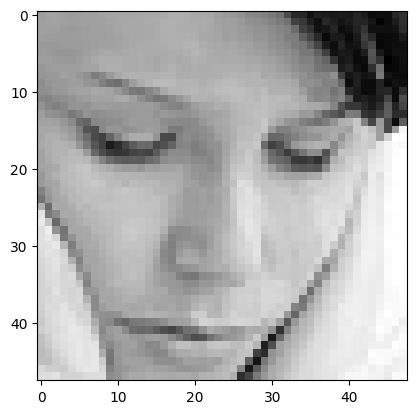

In [37]:
image = 'images/train/sad/42.jpg'
print("original image is of sad")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')

original image is of disgust
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
model prediction is  disgust


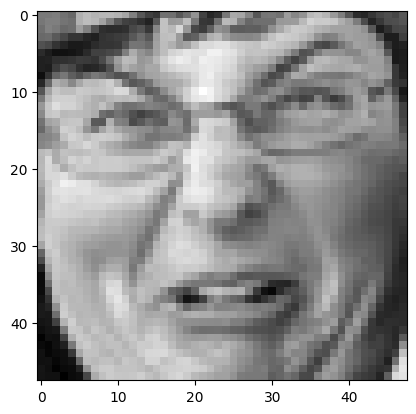

In [38]:
image = 'images/train/disgust/299.jpg'
print("original image is of disgust")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')

original image is of surprise
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
model prediction is  neutral


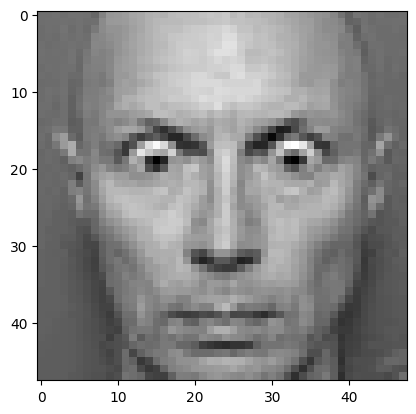

In [39]:
image = 'images/train/surprise/15.jpg'
print("original image is of surprise")
img = ef(image)
pred = model.predict(img)
pred_label = label[pred.argmax()]
print("model prediction is ",pred_label)
plt.imshow(img.reshape(48,48),cmap='gray')